In [15]:
%display latex

In [16]:
# Ініціалізація символьних змінних
var('t x h V gamma m t')

# --- 1. ФІЗИЧНІ КОНСТАНТИ ТА ПАРАМЕТРИ РАКЕТИ (Falcon 1) ---
g0 = 9.80665           # Прискорення вільного падіння (м/с^2)
Re = 6371000.0         # Радіус Землі (м)
rho0 = 1.225           # Щільність повітря на рівні моря (кг/м^3)
H_scale = 8500.0       # Шкала висоти атмосфери (м)

m0 = 27670.0           # Стартова маса (кг)
T = 454000.0           # Тяга двигуна (Н)
Isp = 275.0            # Питомий імпульс (с)
A = 2.27               # Площа лобового опору корпусу (м^2)
Cd = 0.3               # Коефіцієнт лобового опору
mu = T / (Isp * g0)    # Секундна витрата палива (кг/с)

In [17]:
# Функції середовища
rho(h) = rho0 * exp(-h / H_scale)
g(h) = g0 * (Re / (Re + h))^2
D_body(h, V) = 0.5 * Cd * rho(h) * V^2 * A

In [18]:
# СИСТЕМА 1: КЛАСИЧНИЙ СТАРТ (Gravity Turn)# ==============================================================================
eq_x1 = V * cos(gamma)
eq_h1 = V * sin(gamma)
eq_V1 = (T - D_body(h, V)) / m - g(h) * sin(gamma)
eq_gamma1 = -(g(h) / V) * cos(gamma) + (V / (Re + h)) * cos(gamma)
eq_m1 = -mu + 0*t # Початкові умови: [t=0, x=0, h=0.1, V=5.0, gamma=1.56, m=m0] швидкість беремо 10 м/с, кут 1.57 рад (~89.95 градуса) для ініціалізації повороту
ics_classic = [0, 0, 0.1, 10.0, 1.57, m0]
sol_classic = desolve_system_rk4(
    [eq_x1, eq_h1, eq_V1, eq_gamma1, eq_m1],
    [x, h, V, gamma, m],
    ics=ics_classic, ivar=t, end_points=130, step=0.5
)

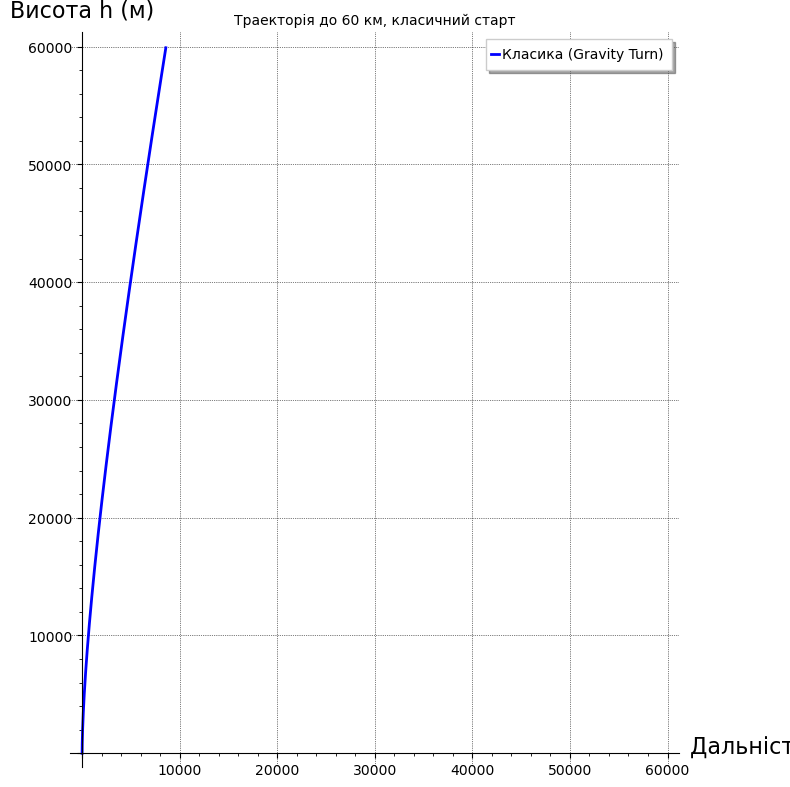

In [19]:
pts_classic = [(pt[1], pt[2]) for pt in sol_classic if pt[2] <= 60000]
plot_c = list_plot(pts_classic, plotjoined=True, color='blue', thickness=2, legend_label='Класика (Gravity Turn)')
trajectory_plot = plot_c
trajectory_plot.show(
    title="Траекторія до 60 км, класичний старт", 
    axes_labels=['Дальність x (м)', 'Висота h (м)'], 
    gridlines=True,
    figsize=(8, 8),      
    xmin=0, xmax=60000,  
    ymin=0, ymax=60000
)

In [20]:
# СИСТЕМА 2: СТАРТ ПІД КУТОМ 45 ГРАДУСІВ ДО ГОРИЗОНТУ (З урахуванням крил та підйомної сили)# ==============================================================================
gamma_fixed = N(pi/4) # 45 градусів
K_wing = 2.5 # Аеродинамічна якість крила
# 1. Величина підйомної сили L (має точно компенсувати, перпендикулярну до вектору тяги, гравітацію)
L(h, m) = m * g(h) * cos(gamma_fixed)
# 2. Індуктивний опір (гальмування при обтіканні)
D_lift(h, m) = L(h, m) / K_wing
# 3. Сумарний опір (корпус + крила)
D_total(h, V, m) = D_body(h, V) + D_lift(h, m)
# --- РІВНЯННЯ РУХУ ---
eq_x2 = V * cos(gamma_fixed)
eq_h2 = V * sin(gamma_fixed)
eq_V2 = (T - D_total(h, V, m)) / m - g(h) * sin(gamma_fixed)
eq_m2 = -mu + 0*t
# Початкові умови (Швидкість 10 м/с, час інтегрування 150 с)
ics_45 = [0, 0, 0.1, 10.0, m0]

# Інтегрування
sol_45 = desolve_system_rk4(
    [eq_x2, eq_h2, eq_V2, eq_m2],
    [x, h, V, m],
    ics=ics_45, ivar=t, end_points=150, step=0.5
)

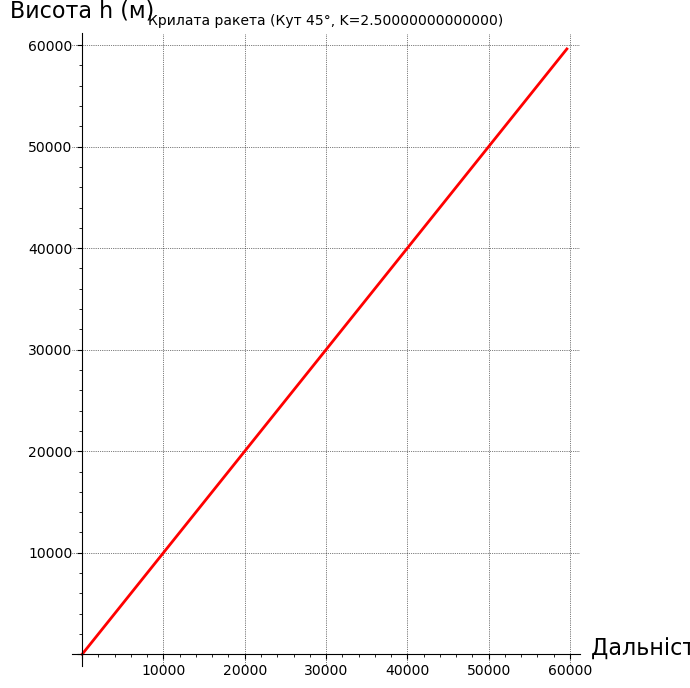

In [ ]:
pts_plot = [(pt[1], pt[2]) for pt in sol_45 if pt[2] <= 60000]
trajectory_plot = list_plot(pts_plot, plotjoined=True, color='red', thickness=2)

trajectory_plot.show(
    title=f"Крилата ракета (Кут 45°, K=round({K_wing}, 2))", 
    axes_labels=['Дальність x (м)', 'Висота h (м)'], 
    gridlines=True,
    figsize=(7, 7),
    xmin=0, xmax=60000,
    ymin=0, ymax=60000
)